# Problema <a class="anchor" id="prob"></a>

Buscamos determinar, dado un
grafo no dirigido de 7 nodos, un camino que conecte el nodo
H con el nodo B bajo la restricción de recorrer cada arista
exactamente una vez. Este es el grafo:

![ejemplo](img/problema_imagen1.png)

Tenemos cinco restricciones y sus representaciones lógicas que debemos implementar para resolver el problema:

1. El recorrido debe comenzar obligatoriamente en el nodo H
$$
\bigvee_{i:(H,i)\in A} \left( To(H,i,0) \wedge \bigwedge_{(j,k)\in A, j \neq H} \neg To(j,k,0) \right)
$$
2. El destino final del recorrido debe ser en el nodo B
$$
\bigvee_{i:(i,B)\in A} \left( To(i,B,7) \wedge \bigwedge_{(j,k)\in A, j \neq B} \neg To(j,k,7) \right)
$$
3. Cada arista del grafo debe ser transitada al menos una vez. 
$$\bigwedge_{(i,j) \in A} \bigwedge_{t \in T} \left( To(i,j,t) \implies \bigwedge_{l \neq t} (\neg To(i,j,l) \wedge \neg To(j,i,l)) \right)$$
4. Ninguna arista puede ser recorrida más de una vez durante la secuencia.   $$\bigwedge_{(i,j) \in A} \bigwedge_{t \in T} \left( To(i,j,t) \implies \bigwedge_{l \neq t} (\neg To(i,j,l) \wedge \neg To(j,i,l)) \right)$$
5. El vértice de salida en el turno $t$ debe ser el mismo que el vértice de llegada del turno.$$\bigwedge_{t \in T-\{1\}}\left( \bigwedge_{(i,j) \in A}\left(To(i,j,t-1)\implies \bigvee_{k:(j,k)\in A} To(j,k, t)\right) \right) $$

## Implementación de las restricciones
En la librería `grafos` hemos implementado las cinco reglas. Puede correr el siguiente código para visualizar el resultado y puede entrar a la librería para explorar la implementación:

In [1]:
from logica import*   
from grafos import*

In [2]:
g = Grafos()

Observe que el objeto tiene un atributo `reglas`, en el cual está una lista con las cinco reglas implementadas en Python:

In [4]:
g.reglas

['(((((((((((((((((ĐY-đ)Y-Ē)Y-ē)Y-Ĕ)Y-ĕ)Y-Ė)Y-ė)Y-Ę)Y-ę)Y-Ě)Y-ě)Y-Ĝ)Y-ĝ)Y-Ğ)Y-ğ)O(((((((((((((((ĒY-Đ)Y-đ)Y-ē)Y-Ĕ)Y-ĕ)Y-Ė)Y-ė)Y-Ę)Y-ę)Y-Ě)Y-ě)Y-Ĝ)Y-ĝ)Y-Ğ)Y-ğ))O(((((((((((((((ĔY-Đ)Y-đ)Y-Ē)Y-ē)Y-ĕ)Y-Ė)Y-ė)Y-Ę)Y-ę)Y-Ě)Y-ě)Y-Ĝ)Y-ĝ)Y-Ğ)Y-ğ))',
 '(((ƂY((((((((((((((-ƀY-Ɓ)Y-ƃ)Y-Ƅ)Y-ƅ)Y-Ɔ)Y-Ƈ)Y-ƈ)Y-Ɖ)Y-Ɗ)Y-Ƌ)Y-ƌ)Y-ƍ)Y-Ǝ)Y-Ə))O(ƈY((((((((((((((-ƀY-Ɓ)Y-Ƃ)Y-ƃ)Y-Ƅ)Y-ƅ)Y-Ɔ)Y-Ƈ)Y-Ɖ)Y-Ɗ)Y-Ƌ)Y-ƌ)Y-ƍ)Y-Ǝ)Y-Ə)))O(ƋY((((((((((((((-ƀY-Ɓ)Y-Ƃ)Y-ƃ)Y-Ƅ)Y-ƅ)Y-Ɔ)Y-Ƈ)Y-ƈ)Y-Ɖ)Y-Ɗ)Y-ƌ)Y-ƍ)Y-Ǝ)Y-Ə)))',
 '(((((((((((((((((((((((ĀY((((((((((((((-āY-Ă)Y-ă)Y-Ą)Y-ą)Y-Ć)Y-ć)Y-Ĉ)Y-ĉ)Y-Ċ)Y-ċ)Y-Č)Y-č)Y-Ď)Y-ď))O(āY((((((((((((((-ĀY-Ă)Y-ă)Y-Ą)Y-ą)Y-Ć)Y-ć)Y-Ĉ)Y-ĉ)Y-Ċ)Y-ċ)Y-Č)Y-č)Y-Ď)Y-ď)))O(ĂY((((((((((((((-ĀY-ā)Y-ă)Y-Ą)Y-ą)Y-Ć)Y-ć)Y-Ĉ)Y-ĉ)Y-Ċ)Y-ċ)Y-Č)Y-č)Y-Ď)Y-ď)))O(ăY((((((((((((((-ĀY-ā)Y-Ă)Y-Ą)Y-ą)Y-Ć)Y-ć)Y-Ĉ)Y-ĉ)Y-Ċ)Y-ċ)Y-Č)Y-č)Y-Ď)Y-ď)))O(ĄY((((((((((((((-ĀY-ā)Y-Ă)Y-ă)Y-ą)Y-Ć)Y-ć)Y-Ĉ)Y-ĉ)Y-Ċ)Y-ċ)Y-Č)Y-č)Y-Ď)Y-ď)))O(ąY((((((((((((((-ĀY-ā)Y-Ă)Y-ă)Y-Ą)Y-Ć)Y-ć)Y-Ĉ)Y-ĉ)Y-Ċ)Y-ċ)Y-Č)Y-č)Y-Ď)Y-ď)))O(ĆY((((((((((((((-ĀY-ā)Y-Ă)Y-ă)

La clase `Grafos` crea de una vez el descriptor `To`, mediante el cual podemos decodificar las letras:

In [5]:
g.To.escribir('ć')

'El vértice A va al vértice G en el turno 0'

También podemos revisar regla por regla. Observe que las fórmulas incluyen un método `ver` para visualizar más fácilmente las reglas:

In [6]:
A = inorder_to_tree(g.reglas[1])
print(A.ver(g.To))

(((El vértice H va al vértice B en el turno 8 Y (((((((((((((( no El vértice H va al vértice G en el turno 8 Y  no El vértice G va al vértice H en el turno 8) Y  no El vértice B va al vértice H en el turno 8) Y  no El vértice H va al vértice E en el turno 8) Y  no El vértice E va al vértice H en el turno 8) Y  no El vértice G va al vértice A en el turno 8) Y  no El vértice A va al vértice G en el turno 8) Y  no El vértice A va al vértice B en el turno 8) Y  no El vértice B va al vértice A en el turno 8) Y  no El vértice B va al vértice C en el turno 8) Y  no El vértice C va al vértice B en el turno 8) Y  no El vértice C va al vértice D en el turno 8) Y  no El vértice D va al vértice C en el turno 8) Y  no El vértice D va al vértice E en el turno 8) Y  no El vértice E va al vértice D en el turno 8)) O (El vértice A va al vértice B en el turno 8 Y (((((((((((((( no El vértice H va al vértice G en el turno 8 Y  no El vértice G va al vértice H en el turno 8) Y  no El vértice H va al vértic

## Visualización <a class="anchor" id="vis"></a>

Una parte muy importante de la clase `Grafos` es el método que permite visualizar el tablero, dada una interpretación de las reglas proposicionales. Esto es lo que nos permite entender la solución del problema.

El método `visualizar_grafo()` tiene un valor predefinido en sus parámetros, por lo que puede ser llamado sin ningun argumento. Ahora bien, al introducirle un diccionario con átomos del problema siendo verdaderos o falsos, mostrará como se vería este en el grafo del problema

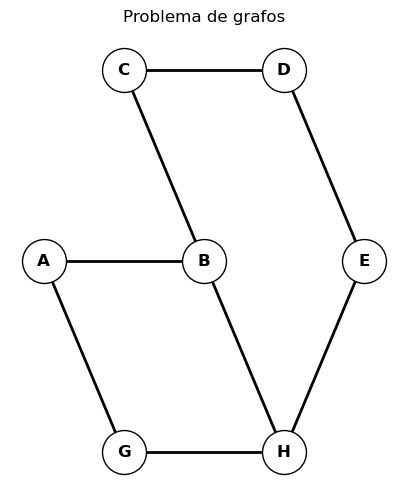

In [7]:
g.visualizar_grafo()

Ahora representemos algun movimiento a través de este método. Esto lo podemos conseguir pasando a visualizar grafos un diccionario correspondiente a las interpretaciones de los átomos del problema.  

Grafiquemos el movmiento del vértice H al vértice G en el turno 1:

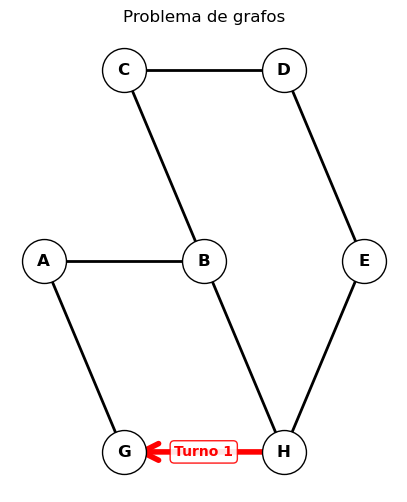

In [7]:
I = {g.To.ravel([("H","G"),1]):True}
g.visualizar_grafo(I)

## Visualización de una solución
El método `visualizar_grafo()` permite ver -dada una interpretación- que movimientos se están haciendo en cada turno. Para demostrar esto, hagamos una de las soluciones del problema :

In [9]:
a1 = g.To.ravel([("H","G"),1]) 
a2 = g.To.ravel([("G","A"),2])  
a3 = g.To.ravel([("A","B"),3]) 
a4 = g.To.ravel([("B","C"),4])  
a5 = g.To.ravel([("C","D"),5]) 
a6 = g.To.ravel([("D","E"),6])  
a7 = g.To.ravel([("E","H"),7])  
a8 = g.To.ravel([("H","B"),8]) 

Observe que si solo estos ocho atomos son verdaderos y el resto de átomos del problema son falsos, encontramos un camino que recorre los 7 vertices de H a B recorriendo cada arista exactamente una vez. Por lo tanto, esta sería una solución al problema. Ahora utilizemos el método `visualizar_grafo()` para visualizar esta solución:

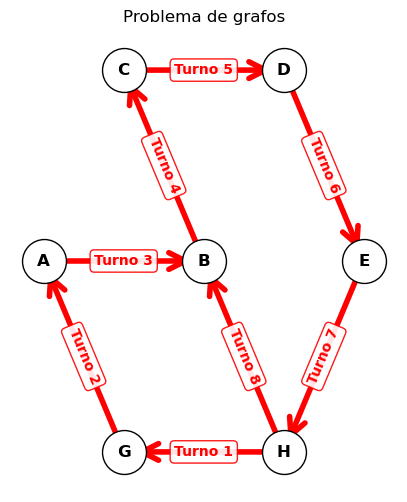

In [11]:
#Interpretación de la solución
I = {a1:True, a2:True, a3:True, a4:True, a5:True, a6:True, a7:True, a8:True} 
#Uso del método 
g.visualizar_grafo(I)

## Tiempos repetidos
¿Qué pasaria si una de las aristas tiene dos turnos o más? 